In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [8]:
pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

# Define your file paths (adjust these to your actual file locations)
xls_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/hdfc_6_months.xls'   # Your XLS file
xlsx_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/sbi online.xlsx'  # Your XLSX file

# Read both bank statements
df_bank1 = pd.read_excel(xls_file)
df_bank2 = pd.read_excel(xlsx_file)

# Preview the data to understand structure
print("Bank 1 (XLS) - First few rows:")
print(df_bank1.head())
print("\nBank 1 columns:", df_bank1.columns.tolist())
print("\n" + "="*50 + "\n")

print("Bank 2 (XLSX) - First few rows:")
print(df_bank2.head())
print("\nBank 2 columns:", df_bank2.columns.tolist())

Bank 1 (XLS) - First few rows:
  HDFC BANK Ltd.                                      Page No .:   1                                          Statement of accounts  \
0                                                NaN                                                                                  
1                                                NaN                                                                                  
2                                                NaN                                                                                  
3                                                NaN                                                                                  
4                         MR      ROHAN JAI SEQUEIRA                                                                                  

  Unnamed: 1 Unnamed: 2 Unnamed: 3                              Unnamed: 4  \
0        NaN        NaN        NaN                                     NaN   
1 

In [11]:
import pandas as pd
import numpy as np

# Read the files with no header first to see raw data
xls_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/hdfc_6_months.xls'   # HDFC
xlsx_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/sbi online.xlsx'  # SBI

# Function to find the header row
def find_header_row(file_path):
    """Display first 30 rows to help locate the transaction table"""
    df = pd.read_excel(file_path, header=None)
    print(f"\n{'='*80}")
    print(f"First 30 rows of {file_path}:")
    print(f"{'='*80}\n")
    for idx in range(min(30, len(df))):
        print(f"Row {idx}: {df.iloc[idx].tolist()}")
    return df

# Examine both files
df_hdfc_raw = find_header_row(xls_file)
df_sbi_raw = find_header_row(xlsx_file)


First 30 rows of /home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/hdfc_6_months.xls:

Row 0: ['HDFC BANK Ltd.                                      Page No .:   1                                          Statement of accounts', nan, nan, nan, nan, nan, nan]
Row 1: [nan, nan, nan, nan, nan, nan, nan]
Row 2: [nan, nan, nan, nan, nan, nan, nan]
Row 3: [nan, nan, nan, nan, nan, nan, nan]
Row 4: [nan, nan, nan, nan, 'Account Branch :KORMANGALA MAIN BRANCH', nan, nan]
Row 5: ['MR      ROHAN JAI SEQUEIRA', nan, nan, nan, 'Address :HDFC BANK LTD,', nan, nan]
Row 6: ['TRRA 72 DAMODHARAM', nan, nan, nan, 'SITE NO 6,B, 20TH MAIN, 7TH BLOCK,', nan, nan]
Row 7: ['AMBALAMUKKU KOWDIAR PO', nan, nan, nan, 'KORMANGALA', nan, nan]
Row 8: ['ADJACENT FAVORITE HOMES', nan, nan, nan, 'City :BENGALURU', nan, nan]
Row 9: ['TRIVANDRUM 695003', nan, nan, nan, 'State :KARNATAKA', nan, nan]
Row 10: [nan, nan, nan, nan, 'Phone no. :18002600/18001600', nan, nan]
Row 11: [nan, nan, nan, nan, 

In [15]:
pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
xls_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/Acct_Statement_XXXXXXXX7651_08022026.xls'
xlsx_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/sbi online.xlsx'

# Read with correct header rows
df_hdfc = pd.read_excel(xls_file, header=20)
df_sbi = pd.read_excel(xlsx_file, header=17)

# Clean up - remove separator rows and NaN rows
df_hdfc = df_hdfc[~df_hdfc['Date'].astype(str).str.contains('\*', na=False)]
df_hdfc = df_hdfc.dropna(how='all')

df_sbi = df_sbi.dropna(how='all')

print("HDFC columns:", df_hdfc.columns.tolist())
print("\nSBI columns:", df_sbi.columns.tolist())
print(f"\nHDFC transactions: {len(df_hdfc)}")
print(f"SBI transactions: {len(df_sbi)}")

HDFC columns: ['Date', 'Narration', 'Chq./Ref.No.', 'Value Dt', 'Withdrawal Amt.', 'Deposit Amt.', 'Closing Balance']

SBI columns: ['Date', 'Details', 'Ref No/Cheque No', 'Debit', 'Credit', 'Balance']

HDFC transactions: 301
SBI transactions: 426


In [18]:
# Rename columns to standard names
hdfc_rename = {
    'Date': 'Date',
    'Narration': 'Description', 
    'Withdrawal Amt.': 'Debit',
    'Deposit Amt.': 'Credit',
    'Closing Balance': 'Balance',
    'Chq./Ref.No.': 'Reference'
}

sbi_rename = {
    'Date': 'Date',
    'Details': 'Description',
    'Debit': 'Debit', 
    'Credit': 'Credit',
    'Balance': 'Balance',
    'Ref No/Cheque No': 'Reference'
}

df_hdfc = df_hdfc.rename(columns=hdfc_rename)
df_sbi = df_sbi.rename(columns=sbi_rename)

# Add bank identifier
df_hdfc['Bank'] = 'HDFC'
df_sbi['Bank'] = 'SBI'

# Select only needed columns
cols = ['Date', 'Description', 'Debit', 'Credit', 'Balance', 'Bank', 'Reference']
df_hdfc = df_hdfc[cols]
df_sbi = df_sbi[cols]

# Combine
df_combined = pd.concat([df_hdfc, df_sbi], ignore_index=True)

# Clean up amounts - remove commas and convert to numeric
df_combined['Debit'] = df_combined['Debit'].astype(str).str.replace(',', '').replace('nan', '0')
df_combined['Credit'] = df_combined['Credit'].astype(str).str.replace(',', '').replace('nan', '0')
df_combined['Balance'] = df_combined['Balance'].astype(str).str.replace(',', '')

df_combined['Debit'] = pd.to_numeric(df_combined['Debit'], errors='coerce').fillna(0)
df_combined['Credit'] = pd.to_numeric(df_combined['Credit'], errors='coerce').fillna(0)
df_combined['Balance'] = pd.to_numeric(df_combined['Balance'], errors='coerce')

# Create net amount column (Credit - Debit)
df_combined['Amount'] = df_combined['Credit'] - df_combined['Debit']

# Convert date (handle both DD/MM/YY and DD/MM/YYYY formats)
df_combined['Date'] = pd.to_datetime(df_combined['Date'], format='mixed', dayfirst=True)

# Sort by date
df_combined = df_combined.sort_values('Date').reset_index(drop=True)

# Display summary
print(f"\nTotal transactions: {len(df_combined)}")
print(f"Date range: {df_combined['Date'].min().strftime('%d-%b-%Y')} to {df_combined['Date'].max().strftime('%d-%b-%Y')}")
print(f"\nTransactions by bank:")
print(df_combined['Bank'].value_counts())
print(f"\nTotal spending (Debit): ₹{df_combined['Debit'].sum():,.2f}")
print(f"Total income (Credit): ₹{df_combined['Credit'].sum():,.2f}")
print(f"Net change: ₹{df_combined['Amount'].sum():,.2f}")

df_combined.head(10)

DateParseError: Unknown datetime string format, unable to parse: STATEMENT SUMMARY  :-, at position 96

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
xls_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/Acct_Statement_XXXXXXXX7651_08022026.xls'
xlsx_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/sbi online.xlsx'

# Read with correct header rows
df_hdfc = pd.read_excel(xls_file, header=20)
df_sbi = pd.read_excel(xlsx_file, header=17)

# Clean up - remove separator rows and NaN rows
df_hdfc = df_hdfc[~df_hdfc['Date'].astype(str).str.contains('\*', na=False)]
df_hdfc = df_hdfc.dropna(how='all')

# Remove footer/summary rows
df_hdfc = df_hdfc[~df_hdfc['Date'].astype(str).str.contains('STATEMENT SUMMARY|Opening Balance|Closing Balance', case=False, na=False)]
df_sbi = df_sbi[~df_sbi['Date'].astype(str).str.contains('STATEMENT SUMMARY|Opening Balance|Closing Balance', case=False, na=False)]

df_sbi = df_sbi.dropna(how='all')

# Rename columns to standard names
hdfc_rename = {
    'Date': 'Date',
    'Narration': 'Description', 
    'Withdrawal Amt.': 'Debit',
    'Deposit Amt.': 'Credit',
    'Closing Balance': 'Balance',
    'Chq./Ref.No.': 'Reference'
}

sbi_rename = {
    'Date': 'Date',
    'Details': 'Description',
    'Debit': 'Debit', 
    'Credit': 'Credit',
    'Balance': 'Balance',
    'Ref No/Cheque No': 'Reference'
}

df_hdfc = df_hdfc.rename(columns=hdfc_rename)
df_sbi = df_sbi.rename(columns=sbi_rename)

# Add bank identifier
df_hdfc['Bank'] = 'HDFC'
df_sbi['Bank'] = 'SBI'

# Select only needed columns
cols = ['Date', 'Description', 'Debit', 'Credit', 'Balance', 'Bank', 'Reference']
df_hdfc = df_hdfc[cols]
df_sbi = df_sbi[cols]

# Combine
df_combined = pd.concat([df_hdfc, df_sbi], ignore_index=True)

# Clean up amounts - remove commas and convert to numeric
df_combined['Debit'] = df_combined['Debit'].astype(str).str.replace(',', '').replace('nan', '0')
df_combined['Credit'] = df_combined['Credit'].astype(str).str.replace(',', '').replace('nan', '0')
df_combined['Balance'] = df_combined['Balance'].astype(str).str.replace(',', '')

df_combined['Debit'] = pd.to_numeric(df_combined['Debit'], errors='coerce').fillna(0)
df_combined['Credit'] = pd.to_numeric(df_combined['Credit'], errors='coerce').fillna(0)
df_combined['Balance'] = pd.to_numeric(df_combined['Balance'], errors='coerce')

# Create net amount column (Credit - Debit)
df_combined['Amount'] = df_combined['Credit'] - df_combined['Debit']

# Convert date - handle errors by coercing invalid dates to NaT
df_combined['Date'] = pd.to_datetime(df_combined['Date'], dayfirst=True, errors='coerce')

# Remove rows where date parsing failed (NaT values)
df_combined = df_combined.dropna(subset=['Date'])

# Sort by date
df_combined = df_combined.sort_values('Date').reset_index(drop=True)

# Display summary
print(f"\nTotal transactions: {len(df_combined)}")
print(f"Date range: {df_combined['Date'].min().strftime('%d-%b-%Y')} to {df_combined['Date'].max().strftime('%d-%b-%Y')}")
print(f"\nTransactions by bank:")
print(df_combined['Bank'].value_counts())
print(f"\nTotal spending (Debit): ₹{df_combined['Debit'].sum():,.2f}")
print(f"Total income (Credit): ₹{df_combined['Credit'].sum():,.2f}")
print(f"Net change: ₹{df_combined['Amount'].sum():,.2f}")

df_combined.head(10)


Total transactions: 709
Date range: 01-Jan-1970 to 08-Feb-2026

Transactions by bank:
Bank
SBI     420
HDFC    289
Name: count, dtype: int64

Total spending (Debit): ₹1,882,149.47
Total income (Credit): ₹1,971,148.00
Net change: ₹88,998.53


/tmp/ipykernel_99184/3970996704.py:71: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_combined['Date'] = pd.to_datetime(df_combined['Date'], dayfirst=True, errors='coerce')


,Date,Description,Debit,Credit,Balance,Bank,Reference,Amount
0,1970-01-01 00:00:00.000023904,NaN,546507.59,529328.33,6725.35,HDFC,NaN,-17179.26
1,2025-09-07 00:00:00.000000000,UPI-LULU INTERNATIONAL S-LULUTRIVANDRUM@YBL-YE...,15.00,0.00,473.61,HDFC,0000176432319642,-15.00
2,2025-09-07 00:00:00.000000000,EMI 138848868 CHQ S1388488680311 0925138848868,18099.00,0.00,5805.61,HDFC,000000000000000,-18099.00
3,2025-09-07 00:00:00.000000000,UPI-LULU INTERNATIONAL S-LULUTRIVANDRUM@AXL-UT...,5317.00,0.00,488.61,HDFC,0000171606219848,-5317.00
4,2025-09-08 00:00:00.000000000,DEP TFR UPI/CR/525133441303/ANEESHA /ICIC/a...,0.00,650.00,2231.61,SBI,NaN,650.00
5,2025-09-08 00:00:00.000000000,DEP TFR UPI/CR/525183268075/ANEESHA /DBSS/a...,0.00,400.00,2631.61,SBI,NaN,400.00
6,2025-09-08 00:00:00.000000000,WDL TFR UPI/DR/101413632293/NETFLIX/HDFC/ne...,499.00,0.00,2132.61,SBI,NaN,-499.00
7,2025-09-08 00:00:00.000000000,WDL TFR UPI/DR/561787724261/ANEESHA /DBSS/a...,500.00,0.00,1632.61,SBI,NaN,-500.00
8,2025-09-08 00:00:00.000000000,WDL TFR UPI/DR/197622999050/Agastya /UTIB/9...,593.00,0.00,1039.61,SBI,NaN,-593.00
9,2025-09-08 00:00:00.000000000,DEP TFR UPI/CR/110960314876/ANEESHA /KKBK/a...,0.00,1500.00,1581.61,SBI,NaN,1500.00


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
xls_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/Acct_Statement_XXXXXXXX7651_08022026.xls'
xlsx_file = '/home/rohanseq48/Git_projects/prenatal-landing-page/FitTogether/statment/sbi online.xlsx'

# Read with correct header rows
df_hdfc = pd.read_excel(xls_file, header=20)
df_sbi = pd.read_excel(xlsx_file, header=17)

# Clean up - remove separator rows and NaN rows
df_hdfc = df_hdfc[~df_hdfc['Date'].astype(str).str.contains('\*', na=False)]
df_hdfc = df_hdfc.dropna(how='all')

# Remove footer/summary rows
df_hdfc = df_hdfc[~df_hdfc['Date'].astype(str).str.contains('STATEMENT SUMMARY|Opening Balance|Closing Balance', case=False, na=False)]
df_sbi = df_sbi[~df_sbi['Date'].astype(str).str.contains('STATEMENT SUMMARY|Opening Balance|Closing Balance', case=False, na=False)]

df_sbi = df_sbi.dropna(how='all')

# Rename columns to standard names
hdfc_rename = {
    'Date': 'Date',
    'Narration': 'Description', 
    'Withdrawal Amt.': 'Debit',
    'Deposit Amt.': 'Credit',
    'Closing Balance': 'Balance',
    'Chq./Ref.No.': 'Reference'
}

sbi_rename = {
    'Date': 'Date',
    'Details': 'Description',
    'Debit': 'Debit', 
    'Credit': 'Credit',
    'Balance': 'Balance',
    'Ref No/Cheque No': 'Reference'
}

df_hdfc = df_hdfc.rename(columns=hdfc_rename)
df_sbi = df_sbi.rename(columns=sbi_rename)

# Add bank identifier
df_hdfc['Bank'] = 'HDFC'
df_sbi['Bank'] = 'SBI'

# Select only needed columns
cols = ['Date', 'Description', 'Debit', 'Credit', 'Balance', 'Bank', 'Reference']
df_hdfc = df_hdfc[cols]
df_sbi = df_sbi[cols]

# Combine
df_combined = pd.concat([df_hdfc, df_sbi], ignore_index=True)

# Clean up amounts - remove commas and convert to numeric
df_combined['Debit'] = df_combined['Debit'].astype(str).str.replace(',', '').replace('nan', '0')
df_combined['Credit'] = df_combined['Credit'].astype(str).str.replace(',', '').replace('nan', '0')
df_combined['Balance'] = df_combined['Balance'].astype(str).str.replace(',', '')

df_combined['Debit'] = pd.to_numeric(df_combined['Debit'], errors='coerce').fillna(0)
df_combined['Credit'] = pd.to_numeric(df_combined['Credit'], errors='coerce').fillna(0)
df_combined['Balance'] = pd.to_numeric(df_combined['Balance'], errors='coerce')

# Create net amount column (Credit - Debit)
df_combined['Amount'] = df_combined['Credit'] - df_combined['Debit']

# Convert date - try different formats for HDFC (DD/MM/YY) and SBI (DD/MM/YYYY)
def parse_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    date_str = str(date_str).strip()
    
    # Try different date formats
    for fmt in ['%d/%m/%y', '%d/%m/%Y', '%d-%m-%Y', '%d-%m-%y']:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            continue
    return pd.NaT

df_combined['Date'] = df_combined['Date'].apply(parse_date)

# Remove rows where date parsing failed or date is before 2020
df_combined = df_combined.dropna(subset=['Date'])
df_combined = df_combined[df_combined['Date'] >= '2020-01-01']

# Sort by date
df_combined = df_combined.sort_values('Date').reset_index(drop=True)

# Display summary
print(f"\n{'='*80}")
print(f"BANK STATEMENT DASHBOARD - 6 MONTHS")
print(f"{'='*80}")
print(f"\nTotal transactions: {len(df_combined)}")
print(f"Date range: {df_combined['Date'].min().strftime('%d-%b-%Y')} to {df_combined['Date'].max().strftime('%d-%b-%Y')}")
print(f"\nTransactions by bank:")
print(df_combined['Bank'].value_counts())
print(f"\n{'='*80}")
print(f"FINANCIAL SUMMARY")
print(f"{'='*80}")
print(f"Total spending (Debit):  ₹{df_combined['Debit'].sum():>15,.2f}")
print(f"Total income (Credit):   ₹{df_combined['Credit'].sum():>15,.2f}")
print(f"Net change:              ₹{df_combined['Amount'].sum():>15,.2f}")
print(f"{'='*80}\n")

# Display first 10 transactions
print("First 10 transactions:")
display_df = df_combined[['Date', 'Bank', 'Description', 'Debit', 'Credit', 'Balance']].head(10).copy()
display_df['Date'] = display_df['Date'].dt.strftime('%d-%b-%Y')
display_df['Description'] = display_df['Description'].str[:50]  # Truncate long descriptions
print(display_df.to_string(index=False))


BANK STATEMENT DASHBOARD - 6 MONTHS

Total transactions: 708
Date range: 07-Sep-2025 to 08-Feb-2026

Transactions by bank:
Bank
SBI     420
HDFC    288
Name: count, dtype: int64

FINANCIAL SUMMARY
Total spending (Debit):  ₹   1,335,641.88
Total income (Credit):   ₹   1,441,819.67
Net change:              ₹     106,177.79

First 10 transactions:
       Date Bank                                        Description   Debit  Credit  Balance
07-Sep-2025 HDFC     EMI 138848868 CHQ S1388488680311 0925138848868 18099.0     0.0  5805.61
07-Sep-2025 HDFC UPI-LULU INTERNATIONAL S-LULUTRIVANDRUM@AXL-UTIB0A  5317.0     0.0   488.61
07-Sep-2025 HDFC UPI-LULU INTERNATIONAL S-LULUTRIVANDRUM@YBL-YESB0Y    15.0     0.0   473.61
08-Sep-2025  SBI  DEP TFR   UPI/CR/525183268075/ANEESHA /DBSS/anees     0.0   400.0  2631.61
08-Sep-2025  SBI  WDL TFR   UPI/DR/101413632293/NETFLIX/HDFC/netfli   499.0     0.0  2132.61
08-Sep-2025  SBI  WDL TFR   UPI/DR/561787724261/ANEESHA /DBSS/anees   500.0     0.0  1632.61
0

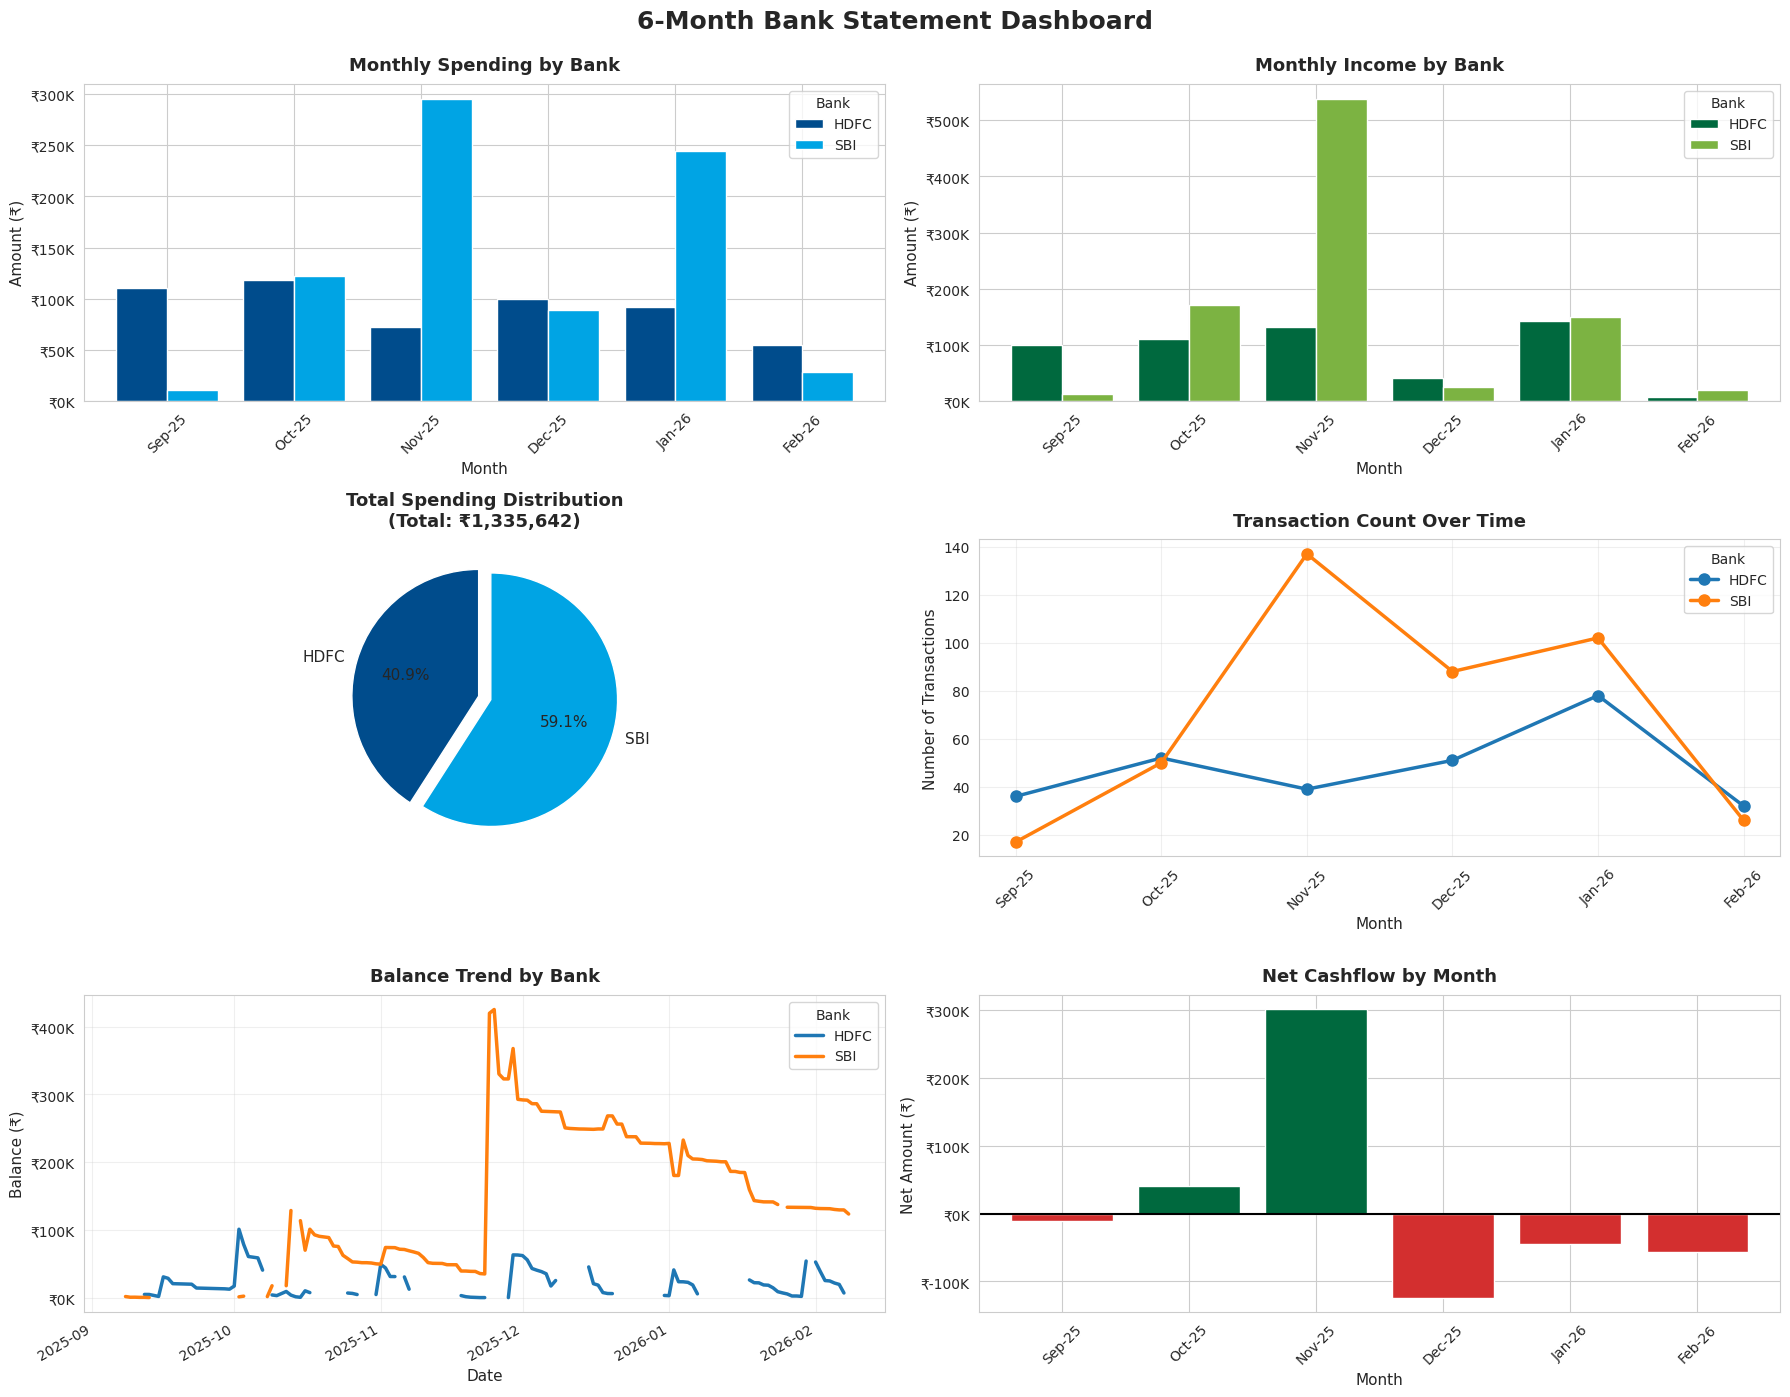


✓ Dashboard saved as 'bank_dashboard.png'


In [23]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create month column for grouping
df_combined['Month'] = df_combined['Date'].dt.to_period('M')
df_combined['Month_str'] = df_combined['Date'].dt.strftime('%b-%y')

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('6-Month Bank Statement Dashboard', fontsize=18, fontweight='bold', y=0.995)

# 1. Monthly spending by bank
monthly_debit = df_combined.groupby(['Month_str', 'Bank'])['Debit'].sum().unstack(fill_value=0)
monthly_debit = monthly_debit.reindex(sorted(monthly_debit.index, key=lambda x: pd.to_datetime(x, format='%b-%y')))
monthly_debit.plot(kind='bar', ax=axes[0, 0], color=['#004c8c', '#00a4e4'], width=0.8)
axes[0, 0].set_title('Monthly Spending by Bank', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Month', fontsize=11)
axes[0, 0].set_ylabel('Amount (₹)', fontsize=11)
axes[0, 0].legend(title='Bank', fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))

# 2. Monthly income by bank
monthly_credit = df_combined.groupby(['Month_str', 'Bank'])['Credit'].sum().unstack(fill_value=0)
monthly_credit = monthly_credit.reindex(sorted(monthly_credit.index, key=lambda x: pd.to_datetime(x, format='%b-%y')))
monthly_credit.plot(kind='bar', ax=axes[0, 1], color=['#00693e', '#7cb342'], width=0.8)
axes[0, 1].set_title('Monthly Income by Bank', fontsize=13, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Month', fontsize=11)
axes[0, 1].set_ylabel('Amount (₹)', fontsize=11)
axes[0, 1].legend(title='Bank', fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))

# 3. Total spending distribution
total_by_bank = df_combined.groupby('Bank')['Debit'].sum()
colors_pie = ['#004c8c', '#00a4e4']
explode = (0.05, 0.05)
axes[1, 0].pie(total_by_bank, labels=total_by_bank.index, autopct='%1.1f%%', 
               colors=colors_pie, startangle=90, explode=explode, textprops={'fontsize': 11})
axes[1, 0].set_title(f'Total Spending Distribution\n(Total: ₹{total_by_bank.sum():,.0f})', 
                     fontsize=13, fontweight='bold', pad=10)

# 4. Transaction count over time
transaction_count = df_combined.groupby(['Month_str', 'Bank']).size().unstack(fill_value=0)
transaction_count = transaction_count.reindex(sorted(transaction_count.index, key=lambda x: pd.to_datetime(x, format='%b-%y')))
transaction_count.plot(kind='line', ax=axes[1, 1], marker='o', linewidth=2.5, markersize=8)
axes[1, 1].set_title('Transaction Count Over Time', fontsize=13, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Number of Transactions', fontsize=11)
axes[1, 1].legend(title='Bank', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# 5. Balance trend by bank
balance_trend = df_combined.groupby(['Date', 'Bank'])['Balance'].last().unstack()
balance_trend.plot(ax=axes[2, 0], linewidth=2.5)
axes[2, 0].set_title('Balance Trend by Bank', fontsize=13, fontweight='bold', pad=10)
axes[2, 0].set_xlabel('Date', fontsize=11)
axes[2, 0].set_ylabel('Balance (₹)', fontsize=11)
axes[2, 0].legend(title='Bank', fontsize=10)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))

# 6. Net cashflow by month
monthly_net = df_combined.groupby('Month_str')['Amount'].sum()
monthly_net = monthly_net.reindex(sorted(monthly_net.index, key=lambda x: pd.to_datetime(x, format='%b-%y')))
colors_bar = ['#00693e' if x > 0 else '#d32f2f' for x in monthly_net]
monthly_net.plot(kind='bar', ax=axes[2, 1], color=colors_bar, width=0.8)
axes[2, 1].set_title('Net Cashflow by Month', fontsize=13, fontweight='bold', pad=10)
axes[2, 1].set_xlabel('Month', fontsize=11)
axes[2, 1].set_ylabel('Net Amount (₹)', fontsize=11)
axes[2, 1].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
axes[2, 1].tick_params(axis='x', rotation=45)
axes[2, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('bank_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Dashboard saved as 'bank_dashboard.png'")

In [24]:
# Top 10 expenses
print("\n" + "="*100)
print("TOP 10 LARGEST EXPENSES")
print("="*100)
top_expenses = df_combined[df_combined['Debit'] > 0].nlargest(10, 'Debit')[['Date', 'Description', 'Debit', 'Bank']].copy()
top_expenses['Date'] = top_expenses['Date'].dt.strftime('%d-%b-%Y')
top_expenses['Description'] = top_expenses['Description'].str[:60]
print(top_expenses.to_string(index=False))

# Summary by month
print("\n" + "="*100)
print("MONTHLY SUMMARY")
print("="*100)
monthly_summary = df_combined.groupby('Month_str').agg({
    'Debit': 'sum',
    'Credit': 'sum',
    'Amount': 'sum'
}).round(2)
monthly_summary = monthly_summary.reindex(sorted(monthly_summary.index, key=lambda x: pd.to_datetime(x, format='%b-%y')))
monthly_summary.columns = ['Total Spent (₹)', 'Total Income (₹)', 'Net (₹)']
print(monthly_summary.to_string())

# Average transaction size
print("\n" + "="*100)
print("AVERAGE TRANSACTION SIZE BY BANK")
print("="*100)
avg_by_bank = df_combined[df_combined['Debit'] > 0].groupby('Bank')['Debit'].agg(['mean', 'median', 'count'])
avg_by_bank.columns = ['Average (₹)', 'Median (₹)', 'Transaction Count']
print(avg_by_bank.round(2).to_string())

# Category breakdown (simple categorization based on keywords)
print("\n" + "="*100)
print("SPENDING BY CATEGORY (Estimated)")
print("="*100)

def categorize_transaction(desc):
    desc = str(desc).upper()
    if any(word in desc for word in ['SWIGGY', 'ZOMATO', 'UBER EATS', 'RESTAURANT', 'FOOD', 'ARYAAS', 'KITCHEN']):
        return 'Food & Dining'
    elif any(word in desc for word in ['EMI', 'LOAN']):
        return 'EMI/Loans'
    elif any(word in desc for word in ['AMAZON', 'FLIPKART', 'SHOPPING', 'LULU']):
        return 'Shopping'
    elif any(word in desc for word in ['NETFLIX', 'PRIME', 'HOTSTAR', 'SPOTIFY', 'PLAY']):
        return 'Entertainment'
    elif any(word in desc for word in ['UBER', 'OLA', 'RAPIDO', 'PETROL', 'FUEL']):
        return 'Transport'
    elif any(word in desc for word in ['ATM', 'CASH']):
        return 'Cash Withdrawal'
    else:
        return 'Others'

df_combined['Category'] = df_combined['Description'].apply(categorize_transaction)
category_spending = df_combined[df_combined['Debit'] > 0].groupby('Category')['Debit'].sum().sort_values(ascending=False)
print(category_spending.to_string())
print(f"\n{'='*100}\n")


TOP 10 LARGEST EXPENSES
       Date                                                   Description   Debit Bank
26-Nov-2025  WDL TFR   UPI/DR/207511494096/GODSPEED/HDFC/godspe\n edim/Pa 82600.0  SBI
29-Nov-2025  WDL TFR   IMPS/533322611189/HDFC-xx651-/\n    0098296162094  75000.0  SBI
30-Jan-2026  WDL TFR   UPI/DR/700619271056/ROHAN JA/HDFC/814702\n 7419/Pa 60000.0  SBI
01-Nov-2025  WDL TFR   UPI/DR/530550695859/ROHAN JA/HDFC/rohan\n seq48/UP 50000.0  SBI
02-Jan-2026  WDL TFR   UPI/DR/358440766391/ROHAN JA/HDFC/814702\n 7419/Pa 47282.0  SBI
16-Oct-2025  WDL TFR   UPI/DR/565544514099/LINI VIJ/SBIN/linivj\n y30@/sh 32000.0  SBI
15-Sep-2025  UPI-SLICE SMALL FINANCE -CCREPAYMENTS@SLC-NESF0SLCUPI-912872 26767.0 HDFC
18-Jan-2026  WDL TFR   UPI/DR/971173188747/ROHAN JA/HDFC/814702\n 7419/Pa 25000.0  SBI
30-Jan-2026  WDL TFR   UPI/DR/603009904542/SBI LIFE/HDFC/sbilif\n eins/UP 23883.0  SBI
07-Sep-2025                EMI 138848868 CHQ S1388488680311 0925138848868 18099.0 HDFC

MONTHLY SUMMARY
 